## Incoherentely pumped THz cavity coupled to a qubit.
Objective of this script:
1. Map of S (and log map as well) for a set of P values. (Choose a fixed $\omega_{THz}$).
- 2 values de $\omega_{THz}$ : in resonance ($\omega_{THz}\sim \Omega$) y detuned. 
2. Plot $\rho(n)$ Vs $n$.
3. For a continum of $n_{th} = \braket{b^\dagger b}$ values (directly fixed by $P$ and $\kappa$), find for each the peak value of the spectrum on the right sideband $S(\omega_S^+)$, and plot it Vs $n_{th}$.
4. Same for left and central peaks. 

PLUS:  Check that indeed $n_{th}$ given by the formula corresponds to $\braket{b^\dagger b}$.
$$ n_{TH} = \frac{P}{\gamma} $$
(RIGHT??)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.signal import find_peaks

Physical parameters

In [6]:
kappa_b = 1 #decay en la cav de THz
kappa_a = 1 # decay en el sensor (debe ser pequeño, pero mayor que g)
gamma = 1e-4 * kappa_b # decay en el qubit

g = 0.001       # acoplo qubit con optico
chi =  0.1*kappa_b      # acoplo qubit con THz

Omega = 200 * kappa_b  # en uds de kappa_b y 1e6 veces mayor que gamma

Na = 2        # truncación de la primera cavidad 
Nb = 20        # segunda cavidad


Operators

In [7]:
# Operadores en el espacio producto tensorial
sx = tensor( sigmax(), qeye(Na), qeye(Nb))
sp = tensor( sigmap(), qeye(Na), qeye(Nb))
sm = tensor( sigmam(), qeye(Na), qeye(Nb))
sz = tensor( sigmaz(), qeye(Na), qeye(Nb))

a = tensor( qeye(2), destroy(Na) , qeye(Nb))
a_plus = a.dag()

b = tensor( qeye(2), qeye(Na), destroy(Nb))
b_plus = b.dag()

# Disipadores
Dissipators0 = []

Dissipators0.append(np.sqrt(gamma) * sm)
Dissipators0.append(np.sqrt(kappa_a) * a)
Dissipators0.append(np.sqrt(kappa_b) * b)

Preparamos el barrido en valores de $\Delta$

In [8]:
npoints = 40

w_b_resonance = 200*kappa_b
w_b_detunned = 300*kappa_b

P_list = np.array([0.1, 0.3, 0.5]) * kappa_b

# eje horizontal (frecuencia espectral)
Delta_a_list = np.linspace(-3*Omega, 3*Omega, npoints)

# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(-2*Omega, 2*Omega, npoints)

### 1.A) Cálculos para el mapa de S en RESONANCIA

In [ ]:
# Diccionario para guardar todos los mapas por valor de w_b
all_S_maps = {}
w_b = w_b_resonance
H0 = (Omega/2) * sx  + w_b * b_plus * b + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b)

# Doble bucle
for idx, P in enumerate(P_list):

    S_map = np.zeros((len(Delta_q_list), len(Delta_a_list)))

    for i, Delta_q in enumerate(Delta_q_list):
        
        for j, Delta_a in enumerate(Delta_a_list):
            
        # Hamiltoniano
            H = H0 + Delta_a * a_plus * a + Delta_q * sz \

            Dissipators  = Dissipators0
            Dissipators.append(np.sqrt(P)*b_plus)
            rho_SS = steadystate(H, Dissipators)
            
            S_map[i, j] = expect(a_plus*a, rho_SS)

    # Guardar el mapa
    all_S_maps[P] = S_map


### 1.B) Cálculos para el mapa de S en DETUNNING

In [ ]:
# Diccionario para guardar todos los mapas por valor de w_b
all_S_mapsD = {}
w_b = w_b_detunned

# Doble bucle
for idx, P in enumerate(P_list):

    S_mapD = np.zeros((len(Delta_q_list), len(Delta_a_list)))

    for i, Delta_q in enumerate(Delta_q_list):
        
        for j, Delta_a in enumerate(Delta_a_list):
            
        # Hamiltoniano
            H = (Omega/2) * sx \
            + Delta_a * a_plus * a + Delta_q * sz \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b)

            rho_SS = steadystate(H, Dissipators)
            
            S_mapD[i, j] = expect(a_plus*a, rho_SS)

    # Guardar el mapa
    all_S_mapsD[P] = S_mapD

Gráficas

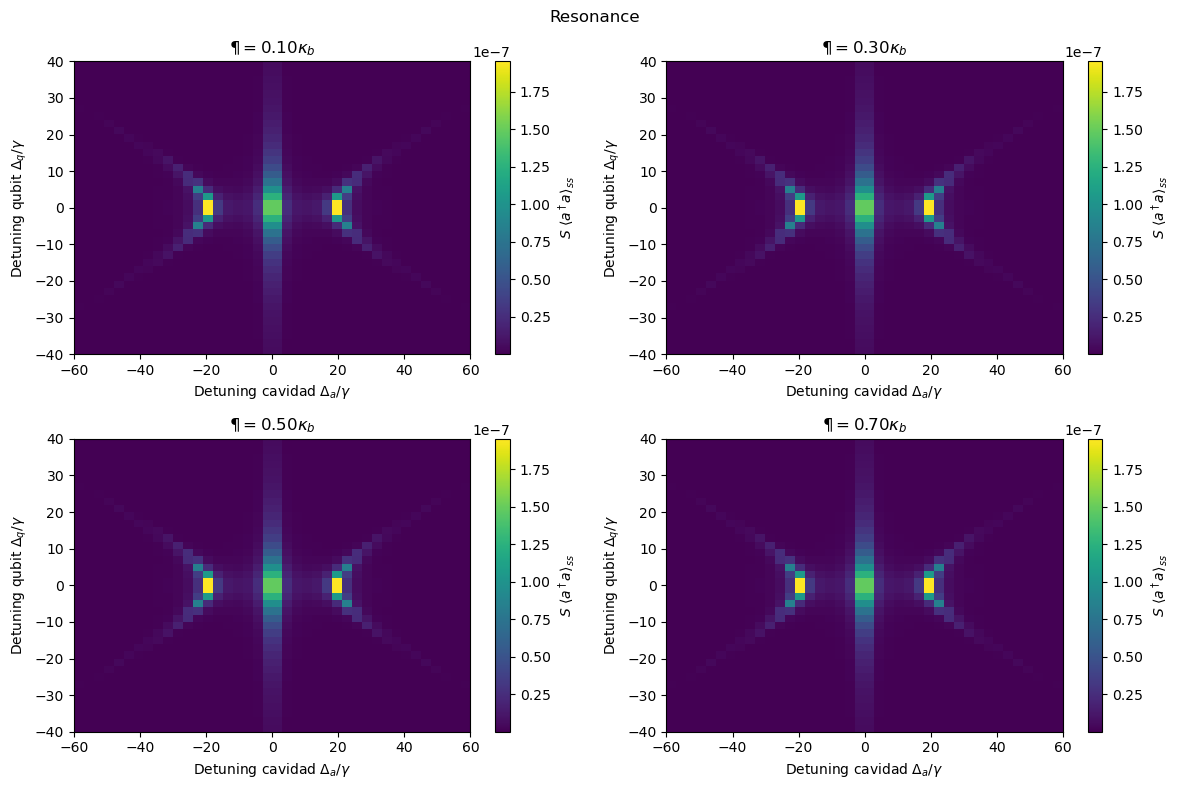

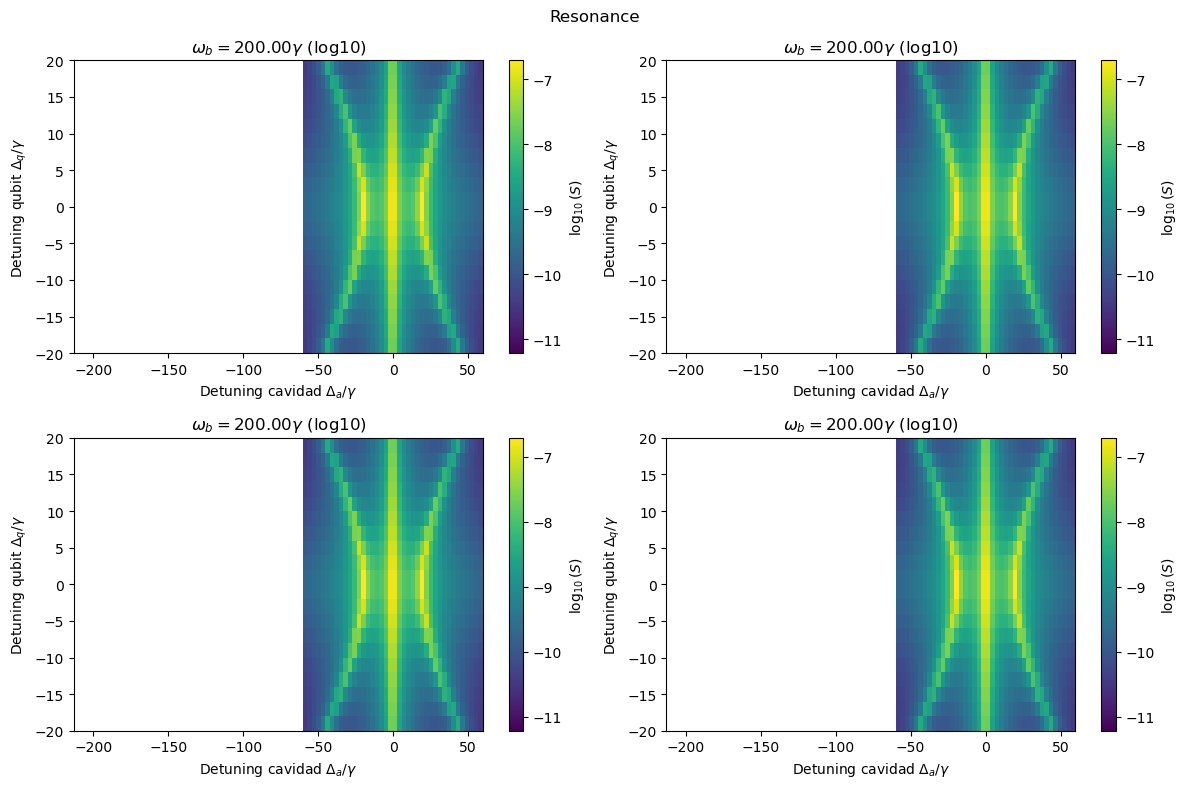

In [ ]:
#---------------------- RESONANCE---------------------
# Crear figuras y ejes
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes = axes.flatten()

fig_log, axes_log = plt.subplots(3, 1, figsize=(12, 8))
axes_log = axes_log.flatten()

for idx, P in enumerate(P_list):

    S_map = all_S_maps[P]   # Recuperar mapa ya calculado
    ax = axes[idx]
    ax_log = axes_log[idx]

    # ------------------------
    # Mapa normal
    # ------------------------
    im = ax.imshow(
        S_map,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    ax.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax.set_ylabel("Detuning qubit $\\Delta_q/\\gamma$")
    ax.set_title(rf"$\P = {P/kappa_b:.2f}\kappa_b$")
    fig.colorbar(im, ax=ax, label=r"$S\ \langle a^\dagger a \rangle_{ss}$")

    # --------------------------
    # Mapa logarítmico
    # --------------------------
    S_log = np.log10(S_map + 1e-12)
    im_log = ax_log.imshow(
        S_log,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    ax_log.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    ax_log.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax_log.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax_log.set_ylabel("Detuning qubit $\\Delta_q/\\gamma$")
    ax_log.set_title(rf"$\omega_b = {w_b:.2f}\gamma$ (log10)")
    ax_log.set_ylim(-20, 20)
    fig_log.colorbar(im_log, ax=ax_log, label=r"$\log_{10}(S)$")

fig.suptitle("Resonance")
fig_log.suptitle("Resonance")
plt.tight_layout()
fig.tight_layout()
fig_log.tight_layout()
plt.show()


### 2. Plot of $\rho(n)$ Vs $n$

Check how the population decreases exponentially at each level.

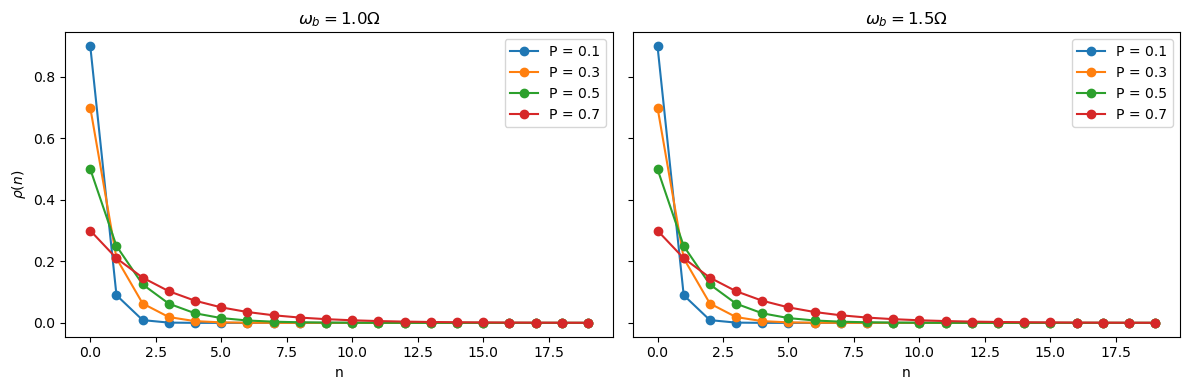

In [ ]:
w_THz_list = [w_b_resonance, w_b_detunned]

Delta_q = 0
Delta_a = 0

rho_n_list = []  # será: [ [rho(P1), rho(P2), ...] para cada w_b ]

for w_b in w_THz_list:
    
    rho_n_wb = []  # lista para este w_b

    for P in P_list:
        
        # IMPORTANTE: aquí debes reconstruir los disipadores con P
        Dissipators = [np.sqrt(gamma) * sm, np.sqrt(kappa_a) * a, np.sqrt(kappa_b) * b, np.sqrt(P) * b_plus]
        
        H = (Omega/2) * sx \
            + Delta_a * a_plus * a \
            + Delta_q * sz \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) \
            + chi * (sz + 1) * (b_plus + b)

        rho_ss = steadystate(H, Dissipators)

        # Traza parcial en modo THz
        rho_mode = ptrace(rho_ss, 2)

        rho_n = [expect(fock_dm(Nb, n), rho_mode) for n in range(Nb)]
        rho_n_wb.append(rho_n)

    rho_n_list.append(rho_n_wb)


# ======== GRÁFICA CON SUBPLOTS ========

n_vals = np.arange(Nb)

fig, axes = plt.subplots(1, len(w_THz_list), figsize=(12, 4), sharey=True)

for i, w_b in enumerate(w_THz_list):
    
    ax = axes[i]

    for j, rho_n in enumerate(rho_n_list[i]):
        ax.plot(n_vals, rho_n, marker='o', label=f'P = {P_list[j]}')

    ax.set_xlabel('n')
    ax.set_title(rf"$\omega_b = {w_b/Omega}\Omega$")
    ax.legend()

axes[0].set_ylabel(r'$\rho(n)$')

plt.tight_layout()
plt.show()

## 3. $S(\omega_S^+)$ Vs $n_{th}$. 
For a continum of $n_{th} = \braket{b^\dagger b}$ values (directly fixed by $P$ and $\kappa$), find for each the peak value of the spectrum on the right sideband $S(\omega_S^+)$, and plot it Vs $n_{th}$.

Also, check validity of the formula that relates $n_{th}$ and $P$




### - Choosing $\Delta_q$ to achieve the peak in the RHS $\omega_S^+$
$\Delta_q$ matches the peak when $\omega_{THz} = \Omega_R$, with $\Omega_R = 2\sqrt{\Delta_q ^2 + \frac{\Omega}{2} }$. Peak will appear at $\Delta_q = \sqrt{ \frac{\omega_{THz}^2}{4}-\frac{\Omega^2}{4}}$.

# ESTO ES SEGURO? NO ES ESTO ASÍ PARA EL PICO IZQ? y quiero el derecho...


In [ ]:
P_list = np.linspace(0.1*kappa_b, 0.7*kappa_b, 50)
S_right = np.ones(len(P_list))

# ESTAMOS EN RESONANCIA
w_b = w_b_resonance
Delta_q = np.sqrt(w_b**2/4 - Omega**2/4)